In [61]:
import numpy as np
import matplotlib.pyplot as plt

In [62]:
def plot_style():
   
    params = {'legend.fontsize': 20,
             'axes.labelsize': 20,
             'axes.titlesize':20,
             'xtick.labelsize':20,
             'ytick.labelsize':20,
             'xtick.major.size':6,
              'xtick.minor.size':4.5,
             'ytick.major.size':6,
              'ytick.minor.size':3.5,
             'figure.facecolor':'w',
              'xtick.major.width':1.5,
              'ytick.major.width':1.5,
              'xtick.minor.width':1.5,
              'ytick.minor.width':1.5,
              'axes.linewidth':1.5,
              'xtick.direction':'in',
              'ytick.direction':'in',
             'ytick.labelleft':True,
              'text.usetex' : False,
             'font.family': 'sans-serif'}
  
    plt.rcParams.update(params)
plot_style()

**PCA demonstration SDSS quasar spectra**

Download data https://drive.google.com/file/d/1bfZ5uCvZAFTJ67mdAges3Bd6VEne3qdM/view?usp=sharing

In [63]:
#from google.colab import drive
#drive.mount('/content/gdrive', force_remount=True)
#root_dir = "/content/gdrive/My Drive/Colab Notebooks/"

In [64]:
import astropy.io.fits as pf
from sklearn.decomposition import  PCA
data = pf.open('clean_spectra.fits')

# data[0].data[N_object,N_pixel]
# data[1].data catalog
# data[2].data log_wavelength

wavelength = 10**data[2].data
import scipy.ndimage as sn
smooth_spectra = np.zeros((len(data[0].data),len(data[0].data[0])))

In [65]:
spec = np.asarray(data[0].data,dtype=np.float64)

In [66]:
for i_object in range(0,len(data[0].data)):
    smooth_spectra[i_object] = sn.median_filter(spec[i_object],21)

Text(0, 0.5, 'Normalized Flux')

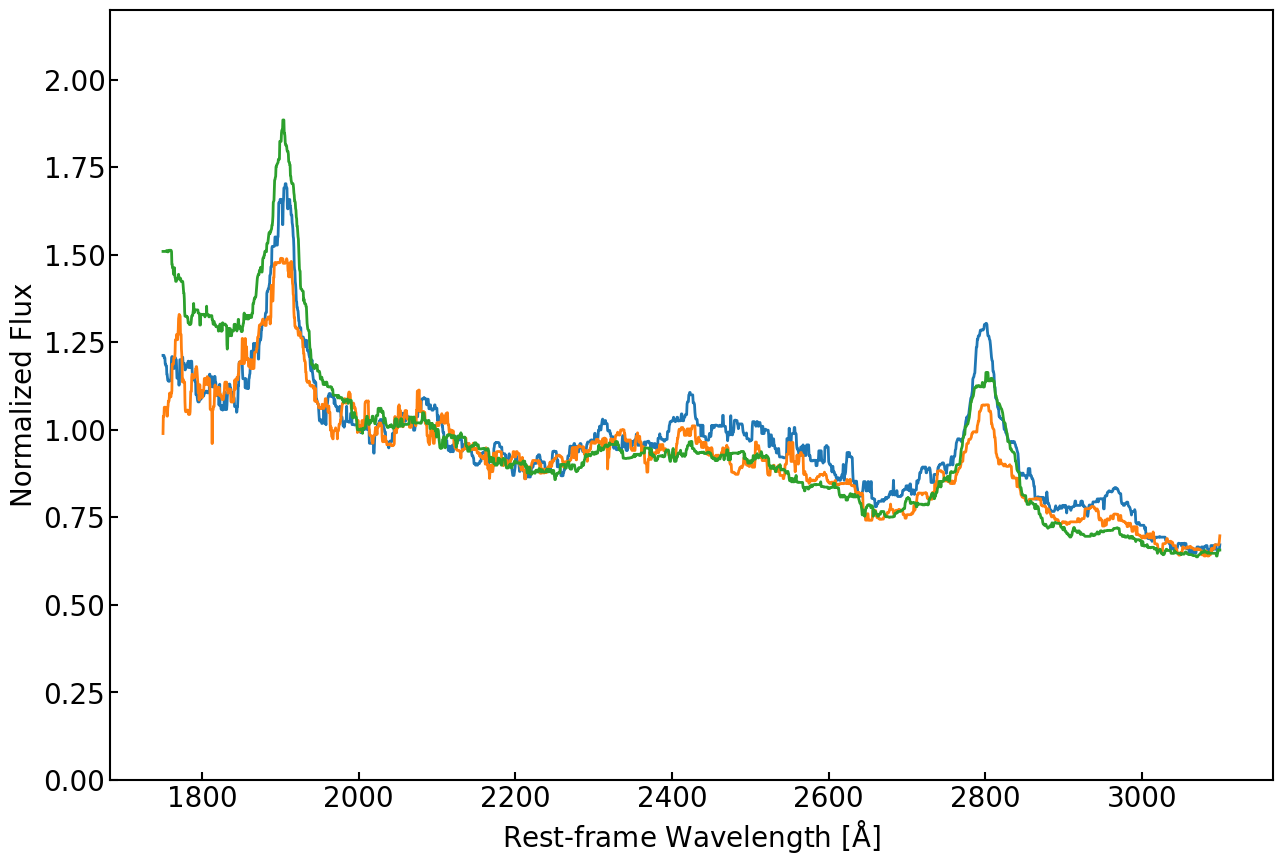

In [68]:
plt.figure(figsize=(15,10))
for i in range(0,3):
    plt.plot(wavelength,smooth_spectra[i,:],lw=2,alpha=1)
    plt.ylim(0,2.2)
plt.xlabel('Rest-frame Wavelength [$\\rm \\AA$]')
plt.ylabel('Normalized Flux')

**Do the PCA and explore the outputs!**
We will discuss together

In [71]:
pca_data = np.copy(smooth_spectra)

In [95]:
pca = PCA(n_components=500)
pca.fit(pca_data)

eigenvectors = pca.components_
coefficient = pca.transform(pca_data)

Text(0.5, 0, 'Wavelength [A]')

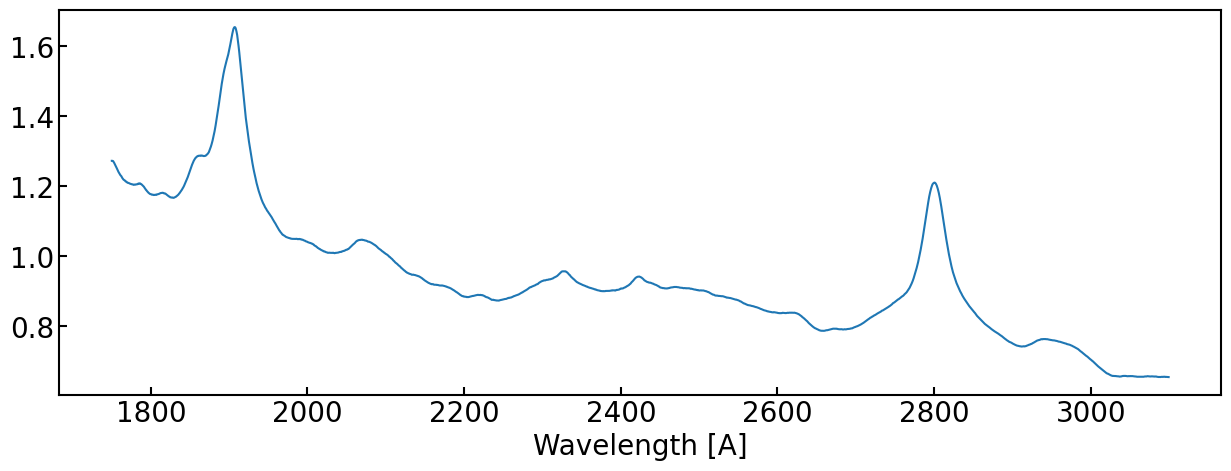

In [96]:
plt.figure(figsize=(15,5))
plt.plot(wavelength,pca.mean_)
plt.xlabel('Wavelength [A]')

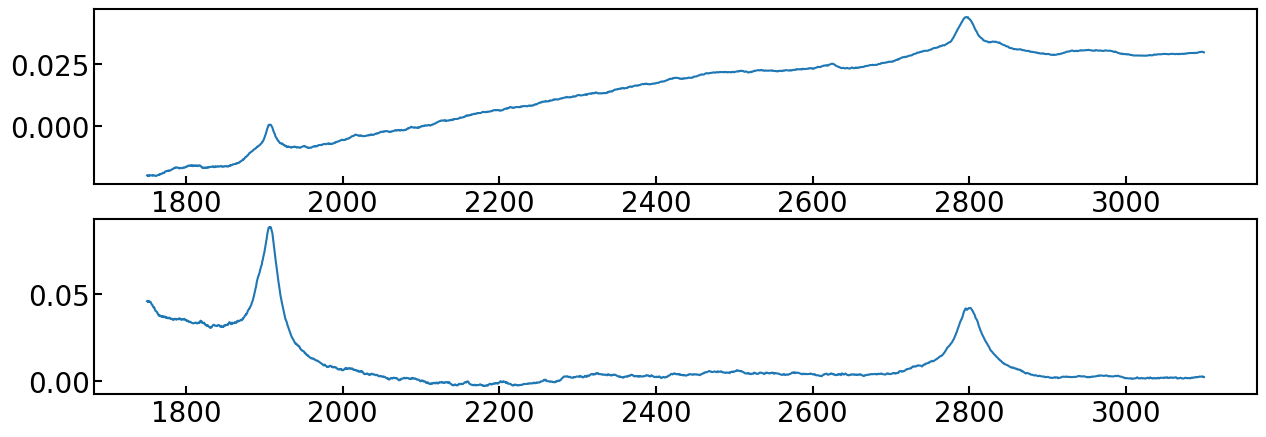

In [97]:
plt.figure(figsize=(15,5))
for i_vector in range(0,2):
    plt.subplot(2,1,i_vector+1)
    plt.plot(wavelength,eigenvectors[i_vector])
    

In [98]:
#print(pca.explained_variance_ratio_)
print(np.sum(pca.explained_variance_ratio_))

0.9970420128420872


**Reconstruction and denoise** 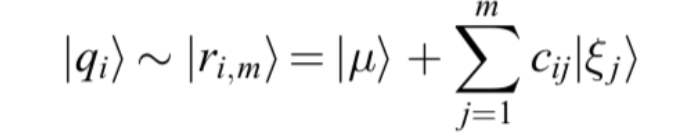

**Tips: you can always reconstruct the original dataset with PCA eigenvectors x coeffcients.**

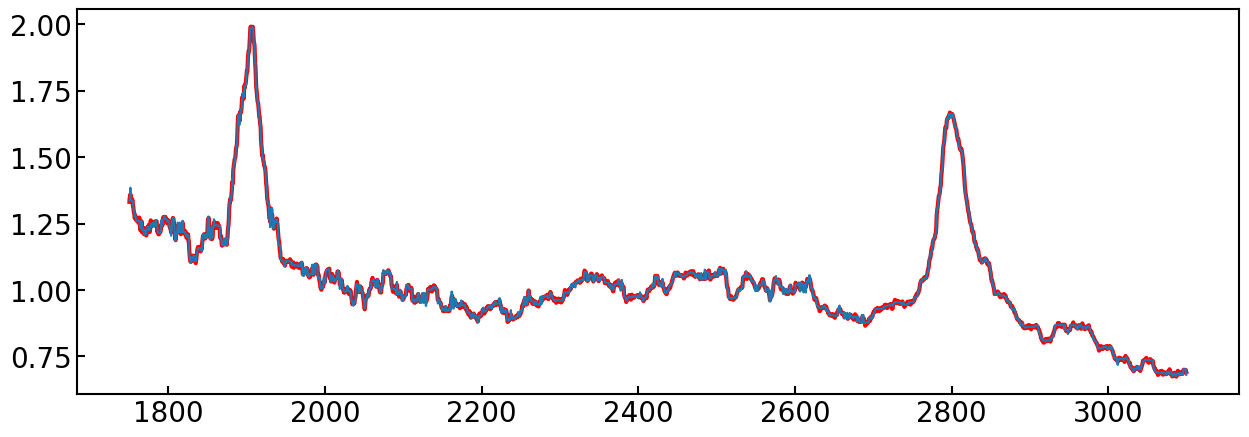

In [104]:
i_object = 105
for i_component in range(0,500):
    if i_component==0:
        reconstructed = coefficient[i_object,i_component]*eigenvectors[i_component,:]
    else:    
        reconstructed+=coefficient[i_object,i_component]*eigenvectors[i_component,:]

total_recontruction = reconstructed+pca.mean_        
        
plt.figure(figsize=(15,5))

plt.plot(wavelength,total_recontruction,color='r',lw=3)
plt.plot(wavelength,smooth_spectra[i_object,:])

**Coefficient exploration**

Text(0, 0.5, 'Coefficient 2')

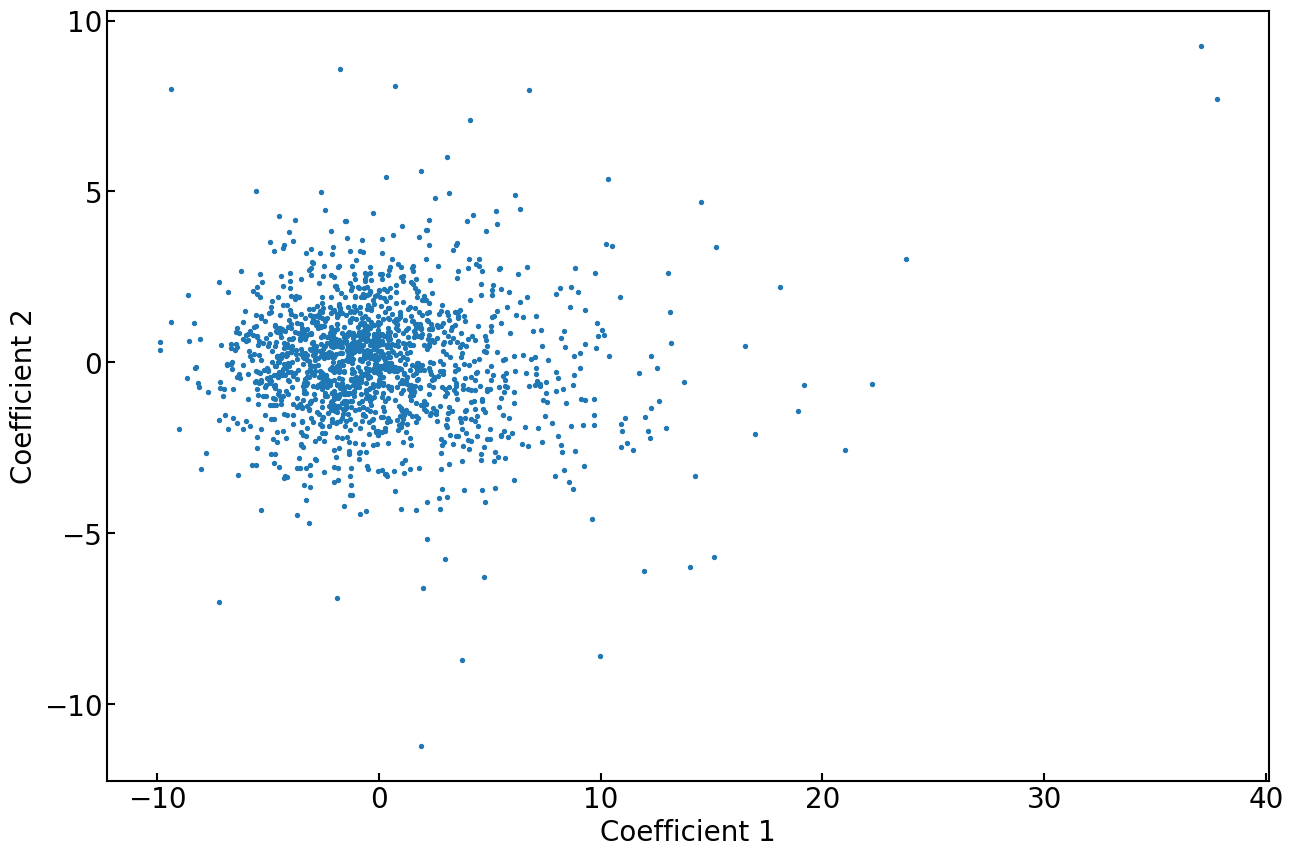

In [105]:
plt.figure(figsize=(15,10))
plt.scatter(coefficient[:,0],coefficient[:,1],s=8)
plt.xlabel('Coefficient 1',fontsize=20)
plt.ylabel('Coefficient 2',fontsize=20)

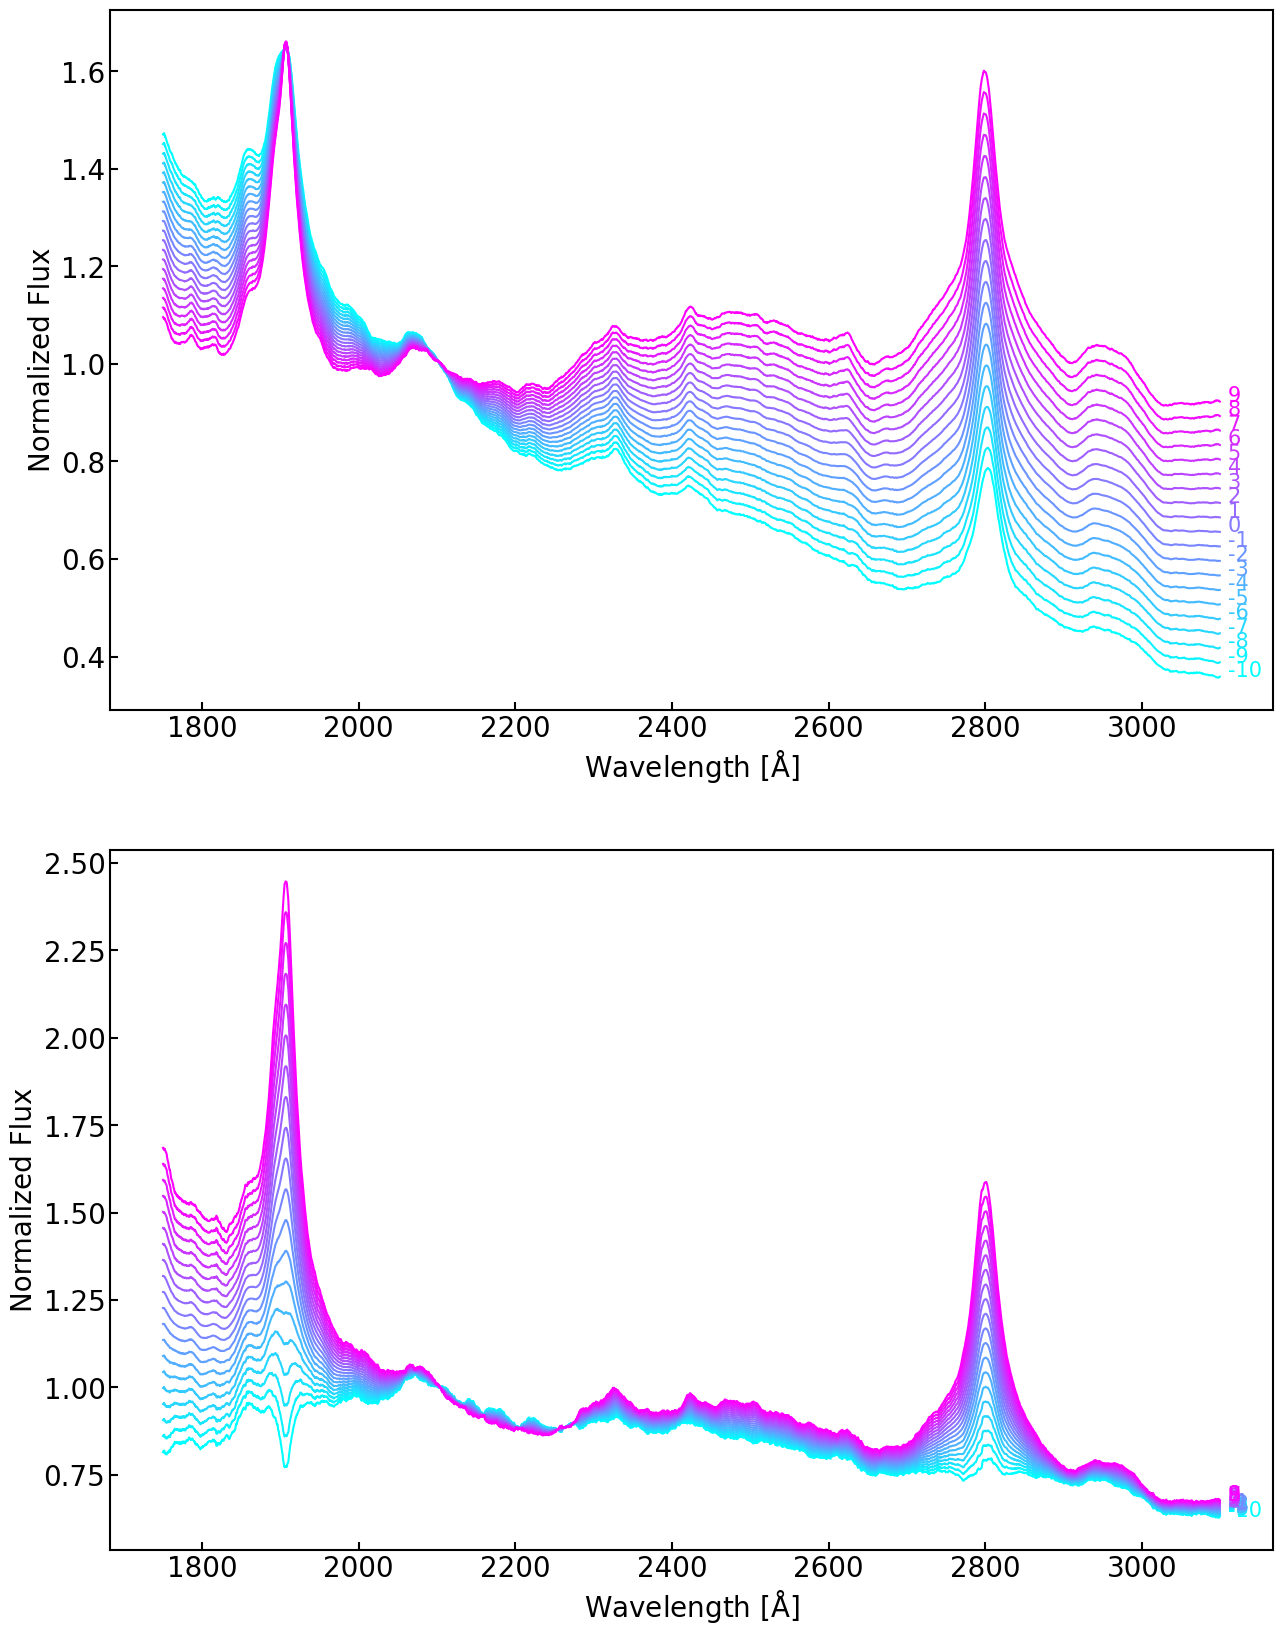

In [47]:
import matplotlib as mpl

cmap = mpl.colormaps['cool']
coefficient_range = np.arange(-10,10,1)
colors = cmap(np.linspace(0.0, 1.0, len(coefficient_range)))

plt.figure(figsize=(15,20))

for i_co in range(0,len(coefficient_range)):
    plt.subplot(2,1,1)
    y = pca.mean_+eigenvectors[0,:]*coefficient_range[i_co]
    plt.plot(wavelength,y,color=colors[i_co])
    plt.text(wavelength[-1]+10,y[-1],'%0.0f' % coefficient_range[i_co],color=colors[i_co],fontsize=15)
    plt.xlabel('Wavelength [$\\rm \\AA$]')
    plt.ylabel('Normalized Flux')    
    
    plt.subplot(2,1,2)
    y = pca.mean_+eigenvectors[1,:]*coefficient_range[i_co]
    plt.plot(wavelength,y,color=colors[i_co])
    plt.text(wavelength[-1]+10,y[-1],'%0.0f' % coefficient_range[i_co],color=colors[i_co],fontsize=15)    
    plt.xlabel('Wavelength [$\\rm \\AA$]')
    plt.ylabel('Normalized Flux')

**Classification**

Text(0, 0.5, 'Coefficient 2')

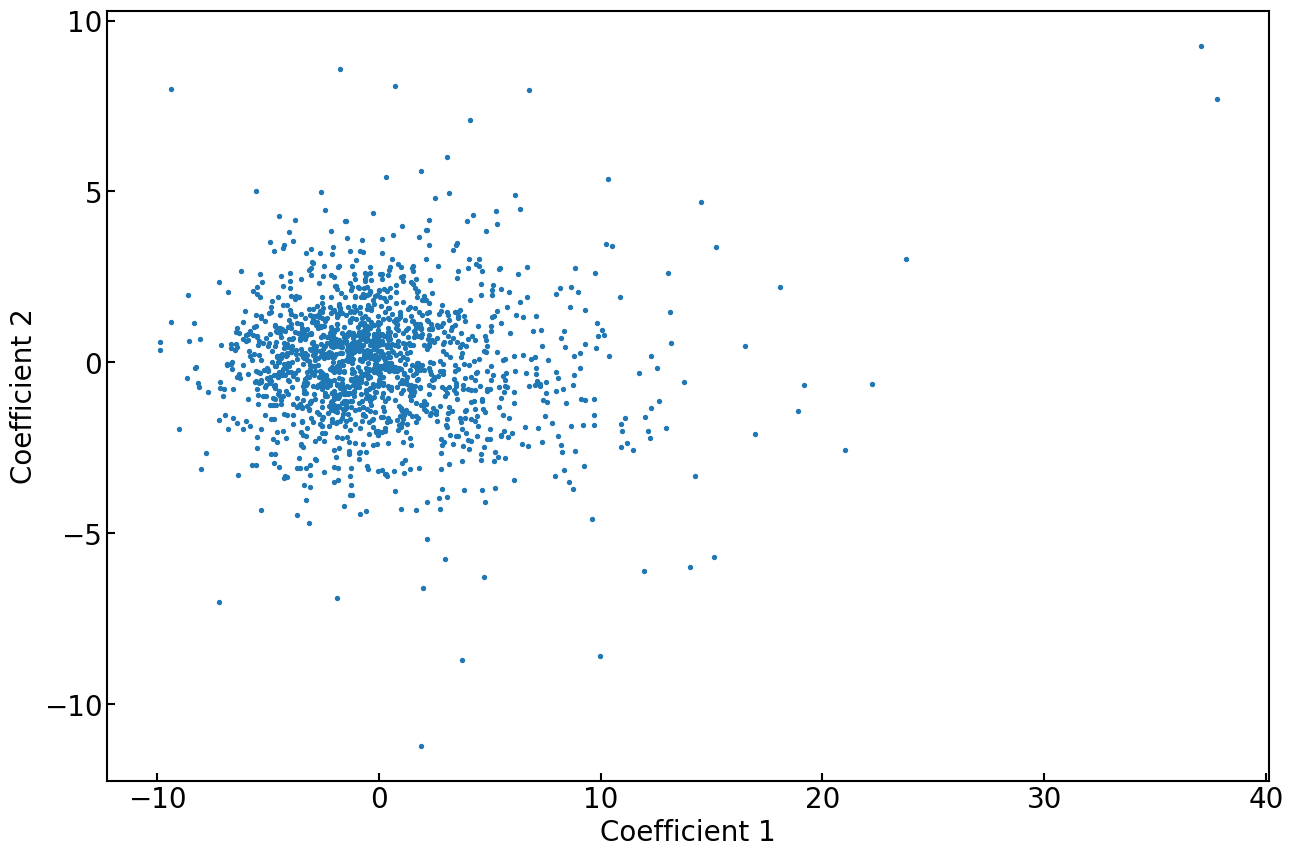

In [106]:
plt.figure(figsize=(15,10))
plt.scatter(coefficient[:,0],coefficient[:,1],s=8)
plt.xlabel('Coefficient 1',fontsize=20)
plt.ylabel('Coefficient 2',fontsize=20)

In [107]:
top_right = (coefficient[:,0]>0) & (coefficient[:,1]>0)
top_left = (coefficient[:,0]<0) & (coefficient[:,1]>0)
bottom_right = (coefficient[:,0]>0) & (coefficient[:,1]<0)
bottom_left = (coefficient[:,0]<0) & (coefficient[:,1]<0)


In [108]:
def median_spectrum(spectra):
    median_spectrum = np.nanmedian(spectra, axis=0)   # shape (n_pixels,)
    
    return median_spectrum

(0.5, 1.8)

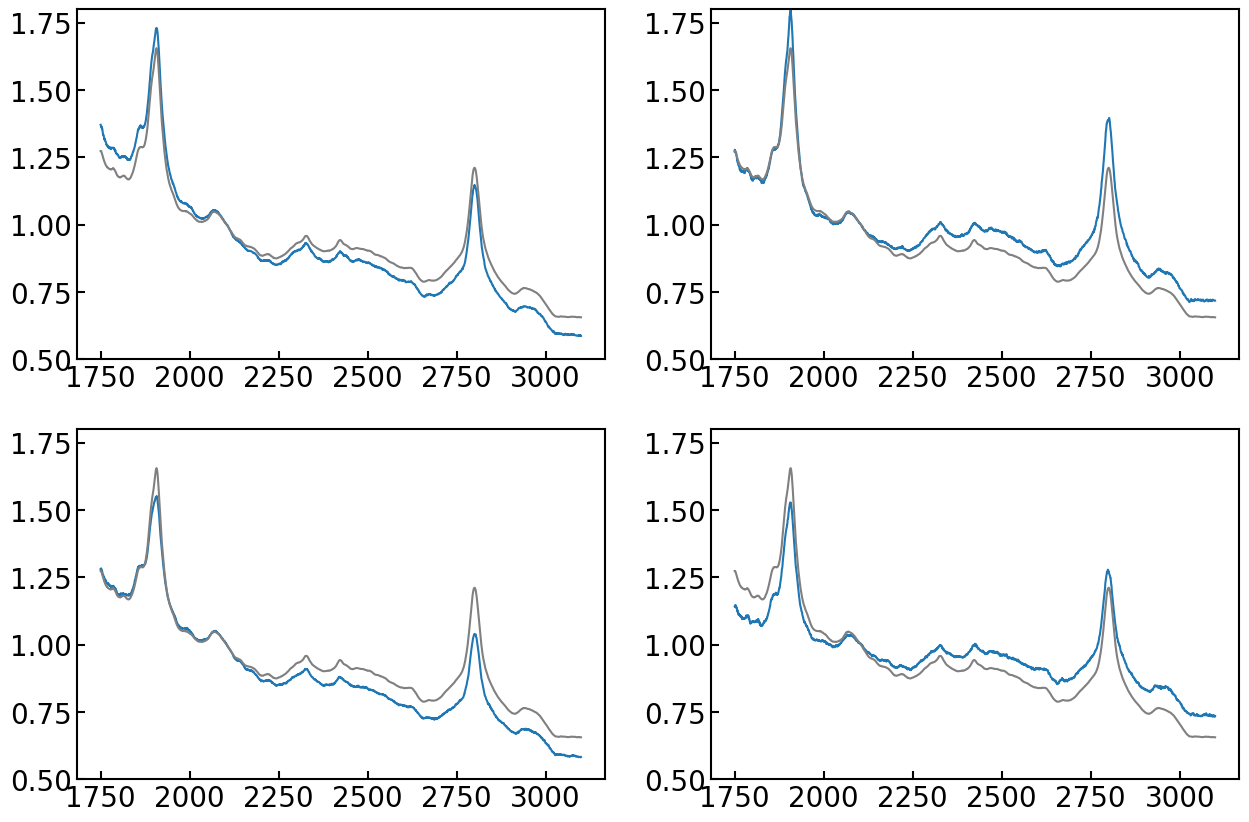

In [109]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
plt.plot(wavelength,median_spectrum(smooth_spectra[top_left,:]))
plt.plot(wavelength,pca.mean_,color='grey')

plt.ylim(0.5,1.8)
plt.subplot(2,2,2)
plt.plot(wavelength,median_spectrum(smooth_spectra[top_right,:]))
plt.plot(wavelength,pca.mean_,color='grey')
plt.ylim(0.5,1.8)
plt.subplot(2,2,3)
plt.plot(wavelength,median_spectrum(smooth_spectra[bottom_left,:]))
plt.plot(wavelength,pca.mean_,color='grey')
plt.ylim(0.5,1.8)
plt.subplot(2,2,4)
plt.plot(wavelength,median_spectrum(smooth_spectra[bottom_right,:]))
plt.plot(wavelength,pca.mean_,color='grey')
plt.ylim(0.5,1.8)

**Outlier**

In [113]:
search = np.where((coefficient[:,0]>30))[0]
print(search)

[ 66 991]


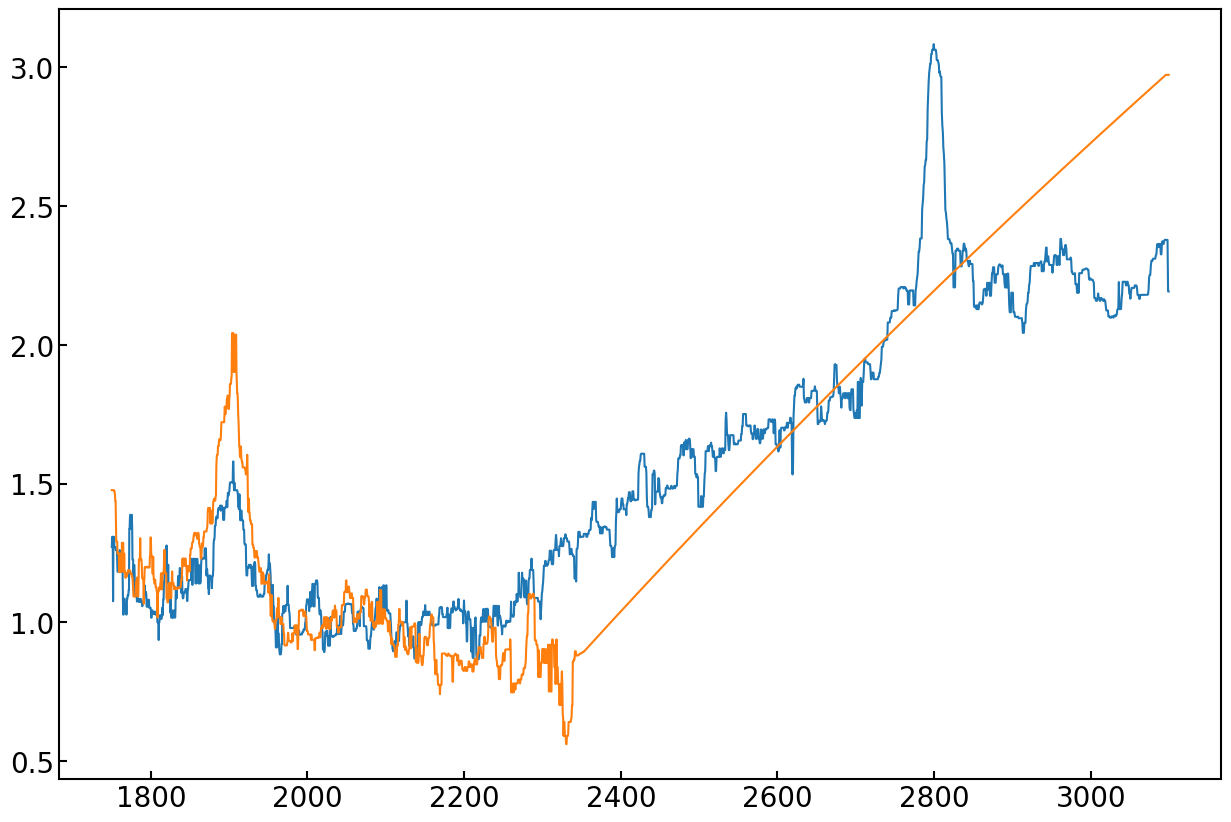

In [114]:
plt.figure(figsize=(15,10))
plt.plot(wavelength,smooth_spectra[66,:])
plt.plot(wavelength,smooth_spectra[991,:])